In [1]:
import os
import sys
import yaml
from pathlib import Path

import math
import argparse
from datetime import date

import numpy as np

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pylab import *

import neptune
from neptune.utils import stringify_unsupported

from src import quantizationf, neuronmodel, mlpsnn, generatedataset
from src.utils import *

plt.style.use('matplotlib_style.mplstyle')

In [2]:
textwidth_in_cm = 15.3
cm_to_inches = 1/2.54

# Generate full dataset n_pres / train acc plot

In [3]:
def get_train_accs(PATH):

    train_acc_arr = np.empty((N_epochs*N_pres,N_seeds))
    train_acc_arr[:] = np.nan
    
    for seed in range(N_seeds):
        train_acc_per_seed = np.array([])
        for epoch in range(N_epochs):
            with open(PATH + f'/seed{seed}/epoch{epoch}_train_labels_and_output_spikes.pkl', 'rb') as f:
                tmp = dill.load(f)
            
            labels = np.array([x[0] for x in tmp])
            output_spike_sums = np.array([x[1] for x in tmp])
            predictions = output_spike_sums.argmax(axis=1)
            
            # split into batches of N_odors
            labels = labels.reshape(-1,N_odors)
            predictions = predictions.reshape(-1,N_odors)
            
            train_acc = (labels==predictions).sum(axis=1)/N_odors
    
            train_acc_per_seed = np.append(train_acc_per_seed, train_acc)
        
        train_acc_arr[:,seed] = train_acc_per_seed
    
    assert not np.isnan(train_acc_arr).any(), "Not all values have been filled"

    return train_acc_arr

In [4]:
# determine best parameter set for a given run

def get_best_param_set(MAIN_PATH, limit_epochs=-1, params_idx=None):
    train_acc_all_params = []
    val_acc_all_params = []
    test_acc_all_params = []
    params_id_arr = []
    if params_idx is None:
        params_idx = range(100)
    for params_id in params_idx:
        try:
            PATH = MAIN_PATH + f'params{params_id}/'
            # get train accs
            train_acc_all_params.append(get_train_accs(PATH))
            # get val and test accs
            val_accs = []
            test_accs = []
            for seed in range(N_seeds):
                with open(PATH + f'seed{seed}/accuracies.pkl', 'rb') as f:
                    accs = dill.load(f)
                val_accs.append(accs['val acc'])
                test_accs.append(accs['test acc'])
            val_acc_all_params.append(val_accs)
            test_acc_all_params.append(test_accs)
            params_id_arr.append(params_id)
        except:
            continue
    
    train_acc_all_params = np.array(train_acc_all_params)
    val_acc_all_params = np.array(val_acc_all_params)
    test_acc_all_params = np.array(test_acc_all_params)

   # this finds the best run at the end of training
    best_param_id_in_avail = np.median(val_acc_all_params, axis=1)[:,limit_epochs].argmax()
    best_param_id_in_paths = params_id_arr[best_param_id_in_avail]
    best_median = np.median(val_acc_all_params[best_param_id_in_avail,:,limit_epochs])
    best_q25 = np.quantile(val_acc_all_params[best_param_id_in_avail,:,limit_epochs], 0.25)
    best_q75 = np.quantile(val_acc_all_params[best_param_id_in_avail,:,limit_epochs], 0.75)
    print(f"Best params until epoch {limit_epochs}: params{best_param_id_in_paths}, best median val acc: {best_median} + {best_q75 - best_median} - {best_median - best_q25}")

    return train_acc_all_params[best_param_id_in_avail], val_acc_all_params[best_param_id_in_avail], test_acc_all_params[best_param_id_in_avail]

## Synthetic dataset

In [5]:
N_odors = 18
N_pres = 15 # number of presentations of each odor in train set
N_epochs = 10
N_seeds = 10

In [6]:
# limit determines how many presentations to take into account
# for calculating the best performance
limit_epochs = 1

train_acc_BPTT_limit, val_acc_BPTT_limit, test_acc_BPTT_limit = get_best_param_set('experiments/exp32_BPTT_early_multiseed/', limit_epochs=limit_epochs)
train_acc_BPTT_full, val_acc_BPTT_full, test_acc_BPTT_full = get_best_param_set('experiments/exp31_BPTT_full_multiseed/')

# train_acc_shallowBPTT_limit, val_acc_shallowBPTT_limit, test_acc_shallowBPTT_limit = get_best_param_set('experiments/exp35_BPTT_no_i2h_learning/', limit_epochs=limit_epochs)
# train_acc_shallowBPTT_full, val_acc_shallowBPTT_full, test_acc_shallowBPTT_full = get_best_param_set('experiments/exp35_BPTT_no_i2h_learning/')

train_acc_FlyModel_limit, val_acc_FlyModel_limit, test_acc_FlyModel_limit = get_best_param_set('experiments/exp34_assoc_early_multiseed/', limit_epochs=limit_epochs)
train_acc_FlyModel_full, val_acc_FlyModel_full, test_acc_FlyModel_full = get_best_param_set('experiments/exp33_assoc_full_multiseed/')

Best params until epoch 1: params0, best median val acc: 0.48333333333333334 + 0.058333333333333404 - 0.04444444444444445
Best params until epoch -1: params0, best median val acc: 0.8222222222222222 + 0.03888888888888886 - 0.0
Best params until epoch 1: params0, best median val acc: 0.6111111111111112 + 0.02777777777777779 - 0.011111111111111294
Best params until epoch -1: params0, best median val acc: 0.6166666666666667 + 0.01666666666666672 - 0.02777777777777779


Get results for Table 1:

In [7]:
np.set_printoptions(precision=2)
for test_after_1_epoch in [test_acc_BPTT_limit.T[1]*100, test_acc_FlyModel_limit.T[1]*100]:
    median = np.median(test_after_1_epoch)
    print("{:.2f}".format(median),
          "{:.2f}".format(median - np.quantile(test_after_1_epoch, q=.25)),
          "{:.2f}".format(np.quantile(test_after_1_epoch, q=.75) - median))

49.44 3.61 3.89
58.89 1.11 3.06


In [8]:
for test_after_all_epochs in [test_acc_BPTT_full.T[-1]*100, test_acc_FlyModel_full.T[-1]*100]:
    median = np.median(test_after_all_epochs)
    print("{:.2f}".format(median),
          "{:.2f}".format(median - np.quantile(test_after_all_epochs, q=.25)),
          "{:.2f}".format(np.quantile(test_after_all_epochs, q=.75) - median))

83.89 1.39 0.56
58.89 1.11 1.94


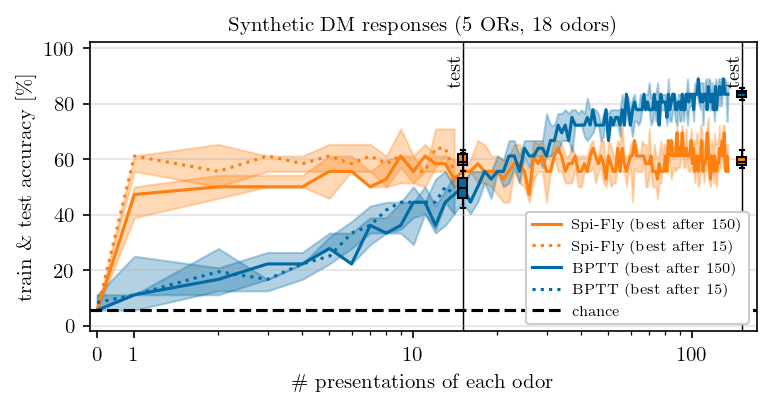

In [9]:
fig, ax = plt.subplots(figsize=(textwidth_in_cm * cm_to_inches / 1.05, 2.5))

ax.set_xscale('symlog', linthresh=1, linscale=0.12)

plt.title("Synthetic DM responses (5 ORs, 18 odors)", fontsize=10)

# train_accs = [train_acc_FlyModel_full, train_acc_FlyModel_limit, train_acc_BPTT_full, train_acc_BPTT_limit, train_acc_shallowBPTT_full, train_acc_shallowBPTT_limit]
# test_accs = [test_acc_FlyModel_full, test_acc_FlyModel_limit, test_acc_BPTT_full, test_acc_BPTT_limit, test_acc_shallowBPTT_full, test_acc_shallowBPTT_limit]
# labels = ['FlyModel (best after 150)', f'FlyModel (best after 15)', 'BPTT (best after 150)', f'BPTT (best after 15)', 'shallow BPTT (best after 150)', f'shallow BPTT (best after 15)']

train_accs = [train_acc_FlyModel_full, train_acc_FlyModel_limit, train_acc_BPTT_full, train_acc_BPTT_limit]
test_accs = [test_acc_FlyModel_full, test_acc_FlyModel_limit, test_acc_BPTT_full, test_acc_BPTT_limit]
labels = ['Spi-Fly (best after 150)', f'Spi-Fly (best after 15)', 'BPTT (best after 150)', f'BPTT (best after 15)']

# train_accs = [train_acc_FlyModel_full, train_acc_BPTT_full]
# labels = ['FlyModel', 'BPTT']
colors = ['C1', 'C1', 'C0', 'C0', 'C5', 'C6']
linestyles = ['solid', ':', 'solid', ':',  'solid', 'solid']
# limits = [-1, -1]
limits = [-1, limit_epochs, -1, limit_epochs, -1, limit_epochs]

for train_acc_arr, label, color, curr_limit, ls in zip(train_accs, labels, colors, limits, linestyles):
    data = train_acc_arr[:curr_limit * N_pres]*100
    median = np.median(data, axis=1)
    q25, q75 = np.quantile(data, 0.25, axis=1), np.quantile(data, 0.75, axis=1)
    x = range(len(data))
    
    # plt.errorbar(x, median, yerr=np.vstack([median-q25, q75-median]))
    ax.plot(median, color=color, label=label, ls=ls)
    ax.fill_between(x, q25, q75, alpha=0.3, color=color)
    
x_positions = [150,15,150,15]
widths = [10, 1, 10, 1]
box_plots = []
    
flierprops = dict(marker=None, markerfacecolor='None', markersize=3,  markeredgecolor='black')
for test_acc_arr, label, color, curr_limit, x_pos, width in zip(test_accs, labels, colors, limits, x_positions, widths):
    data = test_acc_arr[:,curr_limit]*100
    median = np.median(data)
    q25, q75 = np.quantile(data, 0.25), np.quantile(data, 0.75)
    if curr_limit != -1:
        x = curr_limit * N_pres +1
    else:
        x = N_pres * N_epochs
#     ax.errorbar(x-1, median, yerr=np.vstack([median-q25, q75-median]), fmt='x', color=color, markersize='6', zorder=100)

    box_plots.append(
        plt.boxplot(data, patch_artist=True, flierprops=flierprops, positions=[x_pos], widths=width, zorder=100)
    )
    for patch in box_plots[-1]['boxes']:
        patch.set_facecolor(color)
    for median in box_plots[-1]['medians']:
        median.set_color('black')
    

plt.axhline(100/N_odors, alpha = 1.0, ls='--', color='k', label='chance')

plt.xlabel('\# presentations of each odor')
plt.ylabel('train \& test accuracy [\%]')
plt.xlim(-0.2,170)
plt.ylim(-2,102)



major_ticks = [0, 1, 10, 100]
plt.xticks(major_ticks, major_ticks)

minor_ticks = list(range(2,10)) + list(range(20,100,10))
ax.set_xticks(minor_ticks, minor=True)

plt.grid(alpha=0.3, axis='y', linewidth=1.0)
# plt.axvline(1, alpha=0.3, color='k', linewidth=0.3)
plt.axvline(15, alpha=1.0, color='k', linewidth=0.7, zorder=-100)
plt.axvline(150, alpha=1.0, color='k', linewidth=0.7, zorder=-1)
plt.legend(prop={'size': 7}, framealpha=1.0)
plt.text(13,87,"test", rotation="vertical")
plt.text(130,87,"test", rotation="vertical")
plt.savefig('saved_figs/synth_full_dataset.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Gas sensor dataset

In [10]:
N_odors = 10
N_pres = 12 # number of presentations of each odor in train set
N_epochs = 10
N_seeds = 10

In [11]:
# limit determines how many presentations to take into account
# for calculating the best performance
limit_epochs = 1

train_acc_BPTT_limit, val_acc_BPTT_limit, test_acc_BPTT_limit = get_best_param_set('experiments/exp39_gas_BPTT_early_multiseed/', limit_epochs=limit_epochs)
train_acc_BPTT_full, val_acc_BPTT_full, test_acc_BPTT_full = get_best_param_set('experiments/exp40_gas_BPTT_full_multiseed/')

# train_acc_shallowBPTT_limit, val_acc_shallowBPTT_limit, test_acc_shallowBPTT_limit = get_best_param_set('experiments/exp35_BPTT_no_i2h_learning/', limit_epochs=limit_epochs)
# train_acc_shallowBPTT_full, val_acc_shallowBPTT_full, test_acc_shallowBPTT_full = get_best_param_set('experiments/exp35_BPTT_no_i2h_learning/')

train_acc_FlyModel_limit, val_acc_FlyModel_limit, test_acc_FlyModel_limit = get_best_param_set('experiments/exp41_gas_assoc_early_multiseed/', limit_epochs=limit_epochs)
train_acc_FlyModel_full, val_acc_FlyModel_full, test_acc_FlyModel_full = get_best_param_set('experiments/exp42_gas_assoc_full_multiseed/')

Best params until epoch 1: params0, best median val acc: 0.5375000000000001 + 0.05625000000000002 - 0.05625000000000013
Best params until epoch -1: params0, best median val acc: 0.95 + 0.018750000000000044 - 0.0
Best params until epoch 1: params0, best median val acc: 0.8875 + 0.012500000000000067 - 0.012499999999999956
Best params until epoch -1: params0, best median val acc: 0.8625 + 0.012499999999999956 - 0.03125000000000011


Get results for Table 1:

In [12]:
np.set_printoptions(precision=2)
for test_after_1_epoch in [test_acc_BPTT_limit.T[1]*100, test_acc_FlyModel_limit.T[1]*100]:
    median = np.median(test_after_1_epoch)
    print("{:.1f}".format(median),
          "{:.1f}".format(median - np.quantile(test_after_1_epoch, q=.25)),
          "{:.1f}".format(np.quantile(test_after_1_epoch, q=.75) - median))

56.3 6.3 3.7
88.8 3.1 1.2


In [13]:
for test_after_all_epochs in [test_acc_BPTT_full.T[-1]*100, test_acc_FlyModel_full.T[-1]*100]:
    median = np.median(test_after_all_epochs)
    print("{:.1f}".format(median),
          "{:.1f}".format(median - np.quantile(test_after_all_epochs, q=.25)),
          "{:.1f}".format(np.quantile(test_after_all_epochs, q=.75) - median))

95.0 4.4 1.9
82.5 2.5 2.5


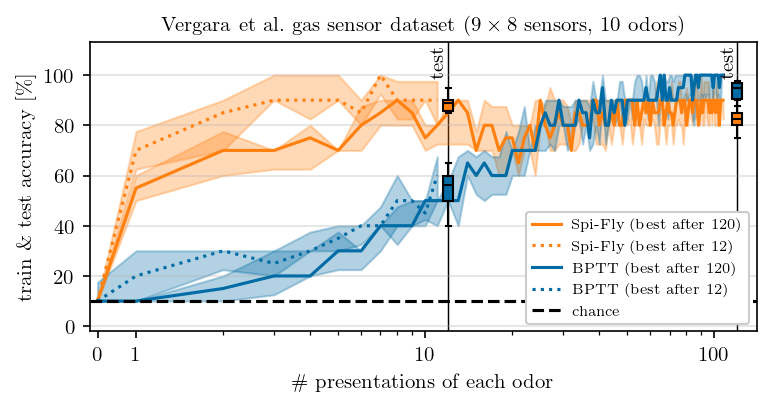

In [14]:
fig, ax = plt.subplots(figsize=(textwidth_in_cm * cm_to_inches / 1.05, 2.5))

ax.set_xscale('symlog', linthresh=1, linscale=0.12)

plt.title("Vergara et al.~gas sensor dataset ($9 \\times 8$ sensors, 10 odors)", fontsize=10)

# train_accs = [train_acc_FlyModel_full, train_acc_FlyModel_limit, train_acc_BPTT_full, train_acc_BPTT_limit, train_acc_shallowBPTT_full, train_acc_shallowBPTT_limit]
# test_accs = [test_acc_FlyModel_full, test_acc_FlyModel_limit, test_acc_BPTT_full, test_acc_BPTT_limit, test_acc_shallowBPTT_full, test_acc_shallowBPTT_limit]
# labels = ['FlyModel (best after 150)', f'FlyModel (best after 15)', 'BPTT (best after 150)', f'BPTT (best after 15)', 'shallow BPTT (best after 150)', f'shallow BPTT (best after 15)']

train_accs = [train_acc_FlyModel_full, train_acc_FlyModel_limit, train_acc_BPTT_full, train_acc_BPTT_limit]
test_accs = [test_acc_FlyModel_full, test_acc_FlyModel_limit, test_acc_BPTT_full, test_acc_BPTT_limit]
labels = ['Spi-Fly (best after 120)', f'Spi-Fly (best after 12)', 'BPTT (best after 120)', f'BPTT (best after 12)']

# train_accs = [train_acc_FlyModel_full, train_acc_BPTT_full]
# labels = ['FlyModel', 'BPTT']
colors = ['C1', 'C1', 'C0', 'C0', 'C5', 'C6']
linestyles = ['solid', ':', 'solid', ':',  'solid', 'solid']
# limits = [-1, -1]
limits = [-1, limit_epochs, -1, limit_epochs, -1, limit_epochs]

for train_acc_arr, label, color, curr_limit, ls in zip(train_accs, labels, colors, limits, linestyles):
    data = train_acc_arr[:curr_limit * N_pres]*100
    median = np.median(data, axis=1)
    q25, q75 = np.quantile(data, 0.25, axis=1), np.quantile(data, 0.75, axis=1)
    x = range(len(data))
    
    # plt.errorbar(x, median, yerr=np.vstack([median-q25, q75-median]))
    ax.plot(median, color=color, label=label, ls=ls)
    ax.fill_between(x, q25, q75, alpha=0.3, color=color)
    
x_positions = [120,12,120,12]
widths = [10, 1, 10, 1]
box_plots = []
    
flierprops = dict(marker=None, markerfacecolor='None', markersize=3,  markeredgecolor='black')
for test_acc_arr, label, color, curr_limit, x_pos, width in zip(test_accs, labels, colors, limits, x_positions, widths):
    data = test_acc_arr[:,curr_limit]*100
    median = np.median(data)
    q25, q75 = np.quantile(data, 0.25), np.quantile(data, 0.75)
    if curr_limit != -1:
        x = curr_limit * N_pres +1
    else:
        x = N_pres * N_epochs
#     ax.errorbar(x-1, median, yerr=np.vstack([median-q25, q75-median]), fmt='x', color=color, markersize='6', zorder=100)

    box_plots.append(
        plt.boxplot(data, patch_artist=True, flierprops=flierprops, positions=[x_pos], widths=width, zorder=100)
    )
    for patch in box_plots[-1]['boxes']:
        patch.set_facecolor(color)
    for median in box_plots[-1]['medians']:
        median.set_color('black')
    

plt.axhline(100/N_odors, alpha = 1.0, ls='--', color='k', label='chance')

plt.xlabel('\# presentations of each odor')
plt.ylabel('train \& test accuracy [\%]')
plt.xlim(-0.2,140)
plt.ylim(-2,113)



major_ticks = [0, 1, 10, 100]
plt.xticks(major_ticks, major_ticks)

minor_ticks = list(range(2,10)) + list(range(20,100,10))
ax.set_xticks(minor_ticks, minor=True)

plt.grid(alpha=0.3, axis='y', linewidth=1.0)
# plt.axvline(1, alpha=0.3, color='k', linewidth=0.3)
plt.axvline(12, alpha=1.0, color='k', linewidth=0.7, zorder=-1)
plt.axvline(120, alpha=1.0, color='k', linewidth=0.7, zorder=-1)
plt.text(10.3,100,"test", rotation="vertical")
plt.text(103,100,"test", rotation="vertical")
plt.legend(prop={'size': 7}, framealpha=1.0)
plt.savefig('saved_figs/gas_sensor_full_dataset.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Fixed-bit precision

In [15]:
def get_train_accs(PATH):

    train_acc_arr = np.empty((N_epochs*N_pres,N_seeds))
    train_acc_arr[:] = np.nan
    
    for seed in range(N_seeds):
        train_acc_per_seed = np.array([])
        for epoch in range(N_epochs):
            with open(PATH + f'/seed{seed}/epoch{epoch}_train_labels_and_output_spikes.pkl', 'rb') as f:
                tmp = dill.load(f)
            
            labels = np.array([x[0] for x in tmp])
            output_spike_sums = np.array([x[1] for x in tmp])
            predictions = output_spike_sums.argmax(axis=1)
            
            # split into batches of N_odors
            labels = labels.reshape(-1,N_odors)
            predictions = predictions.reshape(-1,N_odors)
            
            train_acc = (labels==predictions).sum(axis=1)/N_odors
    
            train_acc_per_seed = np.append(train_acc_per_seed, train_acc)
        
        train_acc_arr[:,seed] = train_acc_per_seed
    
    assert not np.isnan(train_acc_arr).any(), "Not all values have been filled"

    return train_acc_arr

In [16]:
# determine best parameter set for a given run

def get_best_param_set(MAIN_PATH, limit_epochs=-1, params_idx=None):
    train_acc_all_params = []
    val_acc_all_params = []
    test_acc_all_params = []
    params_id_arr = []
    if params_idx is None:
        params_idx = range(100)
    for params_id in params_idx:
        try:
            PATH = MAIN_PATH + f'params{params_id}/'
            # get train accs
            train_acc_all_params.append(get_train_accs(PATH))
            # get val and test accs
            val_accs = []
            test_accs = []
            for seed in range(N_seeds):
                with open(PATH + f'seed{seed}/accuracies.pkl', 'rb') as f:
                    accs = dill.load(f)
                val_accs.append(accs['val acc'])
                test_accs.append(accs['test acc'])
            val_acc_all_params.append(val_accs)
            test_acc_all_params.append(test_accs)
            params_id_arr.append(params_id)
        except:
            continue
    
    train_acc_all_params = np.array(train_acc_all_params)
    val_acc_all_params = np.array(val_acc_all_params)
    test_acc_all_params = np.array(test_acc_all_params)

   # this finds the best run at the end of training
    best_param_id_in_avail = np.median(val_acc_all_params, axis=1)[:,limit_epochs].argmax()
    best_param_id_in_paths = params_id_arr[best_param_id_in_avail]
    best_median = np.median(val_acc_all_params[best_param_id_in_avail,:,limit_epochs])
    print(f"Best params until epoch {limit_epochs}: params{best_param_id_in_paths}, best median val acc: {best_median}")

    return train_acc_all_params[best_param_id_in_avail], val_acc_all_params[best_param_id_in_avail], test_acc_all_params[best_param_id_in_avail]

## Synthetic dataset

In [17]:
N_odors = 18
N_pres = 15 # number of presentations of each odor in train set
N_epochs = 10
N_seeds = 10

In [18]:
# limit determines how many presentations to take into account
# for calculating the best performance
limit_epochs = 1

_, _, test_acc_BPTT_32bit = get_best_param_set('experiments/exp31_BPTT_full_multiseed/')
_, _, test_acc_BPTT_8bit = get_best_param_set('experiments/exp125_synth_BPTT_8bit_multiseed/')
_, _, test_acc_BPTT_6bit = get_best_param_set('experiments/exp124_synth_BPTT_6bit_multiseed/')
_, _, test_acc_BPTT_4bit = get_best_param_set('experiments/exp120_synth_BPTT_4bit_multiseed/')

_, _, test_acc_FlyModel_32bit = get_best_param_set('experiments/exp33_assoc_full_multiseed/')
_, _, test_acc_FlyModel_8bit = get_best_param_set('experiments/exp123_synth_assoc_8bit_multiseed/')
_, _, test_acc_FlyModel_6bit = get_best_param_set('experiments/exp122_synth_assoc_6bit_multiseed/')
_, _, test_acc_FlyModel_4bit = get_best_param_set('experiments/exp121_synth_assoc_4bit_multiseed/')

Best params until epoch -1: params0, best median val acc: 0.8222222222222222
Best params until epoch -1: params1, best median val acc: 0.7666666666666666
Best params until epoch -1: params1, best median val acc: 0.6722222222222223
Best params until epoch -1: params1, best median val acc: 0.19444444444444445
Best params until epoch -1: params0, best median val acc: 0.6166666666666667
Best params until epoch -1: params0, best median val acc: 0.27222222222222225
Best params until epoch -1: params0, best median val acc: 0.16666666666666666
Best params until epoch -1: params0, best median val acc: 0.3333333333333333


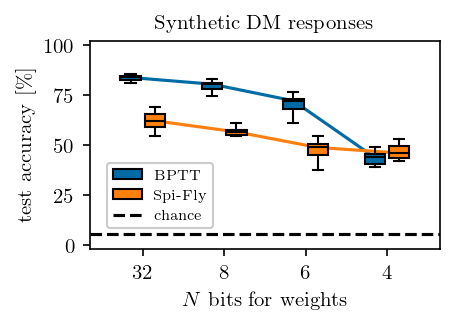

In [19]:
fig, ax = plt.subplots(figsize=(textwidth_in_cm * cm_to_inches / 2.0, 1.8))

# ax.set_xscale('symlog', linthresh=1, linscale=0.12)

plt.title("Synthetic DM responses", fontsize=10)

test_accs_BPTT = [test_acc_BPTT_32bit, test_acc_BPTT_8bit, test_acc_BPTT_6bit, test_acc_BPTT_4bit]
test_accs_BPTT = np.array(test_accs_BPTT)
# get best test accs: for each precision, take median over seeds and find epoch with best test_acc. Then 
test_accs_BPTT = np.array([test_accs_BPTT[i,:,argm] for i, argm in enumerate(np.argmax(np.median(test_accs_BPTT, axis=1), axis=-1))])

test_accs_FlyModel = [test_acc_FlyModel_32bit, test_acc_FlyModel_8bit, test_acc_FlyModel_6bit, test_acc_FlyModel_4bit]
test_accs_FlyModel = np.array(test_accs_FlyModel)
# get best test accs: for each precision, take median over seeds and find epoch with best test_acc. Then 
test_accs_FlyModel = np.array([test_accs_FlyModel[i,:,argm] for i, argm in enumerate(np.argmax(np.median(test_accs_FlyModel, axis=1), axis=-1))])


labels = ['BPTT', 'Spi-Fly']

colors = ['C1', 'C0', 'C4', 'C3', 'C5', 'C6']


width = 0.25
offset = 0.15
x_pos = np.arange(1,5)
flierprops = dict(marker=None, markerfacecolor='None', markersize=3,  markeredgecolor='black')
box_plot1 = plt.boxplot(test_accs_BPTT.T*100, patch_artist=True, flierprops=flierprops, positions=x_pos-offset, widths=width)
for patch, color in zip(box_plot1['boxes'], colors):
    patch.set_facecolor('C0')
for median in box_plot1['medians']:
    median.set_color('black')
    
plt.plot(np.array([1,2,3,4])-offset, np.median(test_accs_BPTT*100, axis=1), c='C0', zorder=-1)


box_plot2 = plt.boxplot(test_accs_FlyModel.T*100, patch_artist=True, flierprops=flierprops, positions=x_pos+offset, widths=width)
for patch, color in zip(box_plot2['boxes'], colors):
    patch.set_facecolor('C1')
for median in box_plot2['medians']:
    median.set_color('black')
    
plt.plot(np.array([1,2,3,4])+offset, np.median(test_accs_FlyModel*100, axis=1), c='C1', zorder=-1)




ll = plt.axhline(100/N_odors, alpha = 1.0, ls='--', color='k', label='chance')

plt.xlabel('$N$ bits for weights')
plt.ylabel('test accuracy [\%]')
plt.ylim(0, 100)

plt.ylim(-2,102)
plt.yticks(range(0,101,25))

plt.xticks([1,2,3,4], labels=[32, 8, 6, 4])

plt.legend([box_plot1["boxes"][0], box_plot2["boxes"][0], ll], ['BPTT', 'Spi-Fly', 'chance'],
           prop={'size': 7}, framealpha=1.0, loc=[0.05, 0.1])

plt.savefig('saved_figs/synth_numbits.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Gas-sensor dataset

In [20]:
N_odors = 10
N_pres = 12 # number of presentations of each odor in train set
N_epochs = 10
N_seeds = 10

In [21]:
# limit determines how many presentations to take into account
# for calculating the best performance
limit_epochs = 1

_, _, test_acc_BPTT_32bit = get_best_param_set('experiments/exp40_gas_BPTT_full_multiseed/')
_, _, test_acc_BPTT_8bit = get_best_param_set('experiments/exp114_gas_BPTT_8bit_multiseed/')
_, _, test_acc_BPTT_6bit = get_best_param_set('experiments/exp115_gas_BPTT_6bit_multiseed/')
_, _, test_acc_BPTT_4bit = get_best_param_set('experiments/exp112_gas_BPTT_multiseed/')

_, _, test_acc_FlyModel_32bit = get_best_param_set('experiments/exp42_gas_assoc_full_multiseed/')
_, _, test_acc_FlyModel_8bit = get_best_param_set('experiments/exp116_gas_assoc_8bit_multiseed/')
_, _, test_acc_FlyModel_6bit = get_best_param_set('experiments/exp117_gas_assoc_6bit_multiseed/')
_, _, test_acc_FlyModel_4bit = get_best_param_set('experiments/exp113_gas_assoc_multiseed/')

Best params until epoch -1: params0, best median val acc: 0.95
Best params until epoch -1: params0, best median val acc: 0.8999999999999999
Best params until epoch -1: params0, best median val acc: 0.7375
Best params until epoch -1: params0, best median val acc: 0.3125
Best params until epoch -1: params0, best median val acc: 0.8625
Best params until epoch -1: params0, best median val acc: 0.7
Best params until epoch -1: params0, best median val acc: 0.6125
Best params until epoch -1: params0, best median val acc: 0.44999999999999996


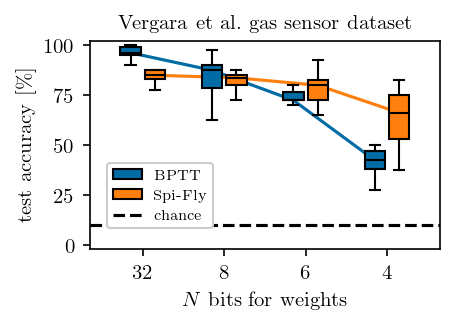

In [22]:
fig, ax = plt.subplots(figsize=(textwidth_in_cm * cm_to_inches / 2.0, 1.8))

# ax.set_xscale('symlog', linthresh=1, linscale=0.12)

plt.title("Vergara et al.~gas sensor dataset", fontsize=10)

test_accs_BPTT = [test_acc_BPTT_32bit, test_acc_BPTT_8bit, test_acc_BPTT_6bit, test_acc_BPTT_4bit]
test_accs_BPTT = np.array(test_accs_BPTT)
# get best test accs: for each precision, take median over seeds and find epoch with best test_acc. Then 
test_accs_BPTT = np.array([test_accs_BPTT[i,:,argm] for i, argm in enumerate(np.argmax(np.median(test_accs_BPTT, axis=1), axis=-1))])

test_accs_FlyModel = [test_acc_FlyModel_32bit, test_acc_FlyModel_8bit, test_acc_FlyModel_6bit, test_acc_FlyModel_4bit]
test_accs_FlyModel = np.array(test_accs_FlyModel)
# get best test accs: for each precision, take median over seeds and find epoch with best test_acc. Then 
test_accs_FlyModel = np.array([test_accs_FlyModel[i,:,argm] for i, argm in enumerate(np.argmax(np.median(test_accs_FlyModel, axis=1), axis=-1))])


labels = ['BPTT', 'Spi-Fly']

colors = ['C1', 'C0', 'C4', 'C3', 'C5', 'C6']


width = 0.25
offset = 0.15
x_pos = np.arange(1,5)
flierprops = dict(marker=None, markerfacecolor='None', markersize=3,  markeredgecolor='black')
box_plot1 = plt.boxplot(test_accs_BPTT.T*100, patch_artist=True, flierprops=flierprops, positions=x_pos-offset, widths=width)
for patch, color in zip(box_plot1['boxes'], colors):
    patch.set_facecolor('C0')
for median in box_plot1['medians']:
    median.set_color('black')
    
plt.plot(np.array([1,2,3,4])-offset, np.median(test_accs_BPTT*100, axis=1), c='C0', zorder=-1)


box_plot2 = plt.boxplot(test_accs_FlyModel.T*100, patch_artist=True, flierprops=flierprops, positions=x_pos+offset, widths=width)
for patch, color in zip(box_plot2['boxes'], colors):
    patch.set_facecolor('C1')
for median in box_plot2['medians']:
    median.set_color('black')

plt.plot(np.array([1,2,3,4])+offset, np.median(test_accs_FlyModel*100, axis=1), c='C1', zorder=-1)



ll = plt.axhline(100/N_odors, alpha = 1.0, ls='--', color='k', label='chance')

plt.xlabel('$N$ bits for weights')
plt.ylabel('test accuracy [\%]')

plt.ylim(-2,102)
plt.yticks(range(0,101,25))

plt.xticks([1,2,3,4], labels=[32, 8, 6, 4])

plt.legend([box_plot1["boxes"][0], box_plot2["boxes"][0], ll], ['BPTT', 'Spi-Fly', 'chance'],
           prop={'size': 7}, framealpha=1.0, loc=[0.05, 0.1])

plt.savefig('saved_figs/gas_sensor_numbits.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Continual learning

## Synthetic dataset

In [23]:
N_odors = 18
N_pres = 15 # number of presentations of each odor in train set
N_epochs = 9
N_seeds = 3

In [24]:
# determine best parameter set for a given run

def get_best_param_set_CL(MAIN_PATH, limit_epochs=-1, params_idx=None):
    val_acc_all_params = []
    test_acc_all_params = []
    params_id_arr = []
    if params_idx is None:
        params_idx = range(100)
    for params_id in params_idx:
        try:
            PATH = MAIN_PATH + f'params{params_id}/'
            # get val and test accs
            val_accs = []
            test_accs = []
            for seed in range(N_seeds):
                with open(PATH + f'seed{seed}/accuracies.pkl', 'rb') as f:
                    accs = dill.load(f)
                val_accs.append(accs['val acc'])
                test_accs.append(accs['test acc'])
            val_acc_all_params.append(val_accs)
            test_acc_all_params.append(test_accs)
            params_id_arr.append(params_id)
        except:
            continue
    
    val_acc_all_params = np.array(val_acc_all_params)
    test_acc_all_params = np.array(test_acc_all_params)
   # this finds the best run at the end of training
    best_param_id_in_avail = np.median(val_acc_all_params, axis=1)[:,limit_epochs].argmax()
    best_param_id_in_paths = params_id_arr[best_param_id_in_avail]
    best_median = np.median(val_acc_all_params[best_param_id_in_avail,:,limit_epochs])
    print(f"Best params until epoch {limit_epochs}: params{best_param_id_in_paths}, best median val acc: {best_median}")

    return None, val_acc_all_params[best_param_id_in_avail], test_acc_all_params[best_param_id_in_avail]

In [25]:
# train_acc_BPTT_CL, val_acc_BPTT_CL, test_acc_BPTT_CL = get_best_param_set_CL('experiments/exp64_synth_CL_BPTT_multiepoch_scan/')
train_acc_BPTT_CL, val_acc_BPTT_CL, test_acc_BPTT_CL = get_best_param_set_CL('experiments/exp51_synth_CL_BPTT_scan/')
train_acc_offline_CL, val_acc_offline_CL, test_acc_offline_CL = get_best_param_set_CL('experiments/exp60_synth_offlineCL_BPTT_reset_scan/')
train_acc_FlyModel_CL, val_acc_FlyModel_CL, test_acc_FlyModel_CL = get_best_param_set_CL('experiments/exp52_synth_CL_assoc_scan/')
train_acc_EWC_CL, val_acc_EWC_CL, test_acc_EWC_CL = get_best_param_set_CL('experiments/exp132_synth_EWC_multiseed/')

Best params until epoch -1: params7, best median val acc: 0.16666666666666666
Best params until epoch -1: params6, best median val acc: 0.8111111111111111
Best params until epoch -1: params20, best median val acc: 0.5888888888888888
Best params until epoch -1: params0, best median val acc: 0.16666666666666666


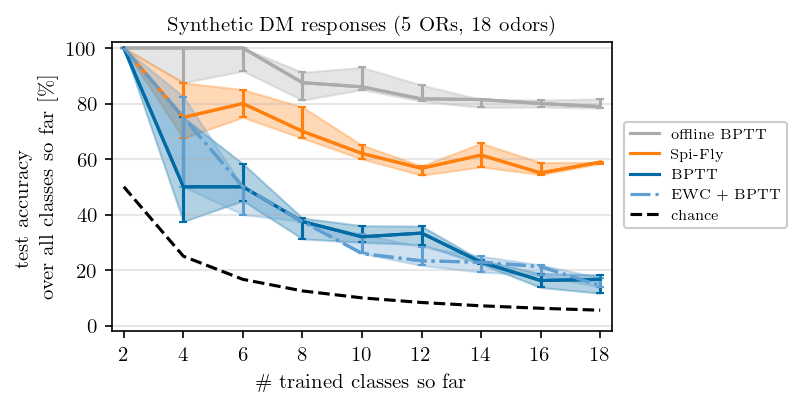

In [26]:
fig, ax = plt.subplots(figsize=(textwidth_in_cm * cm_to_inches / 1.4, 2.5))

plt.title("Synthetic DM responses (5 ORs, 18 odors)", fontsize=10)

chance_levels = 100/(2*np.arange(1,N_epochs+1,1))

test_accs = [test_acc_offline_CL, test_acc_FlyModel_CL, test_acc_BPTT_CL, test_acc_EWC_CL]
epochs_per_odor = [5,1,1,1]
labels = ['offline BPTT', 'Spi-Fly', 'BPTT', 'EWC + BPTT']

colors = ['C2', 'C1', 'C0', 'C4', 'C6']
linestyles = ['solid', 'solid', 'solid', '-.',  'solid', 'solid']

for test_acc_arr, label, color, ls, epo in zip(test_accs, labels, colors, linestyles, epochs_per_odor):
    data = test_acc_arr.T[epo::epo]*100
    median = np.median(data, axis=1)
    q25, q75 = np.quantile(data, 0.25, axis=1), np.quantile(data, 0.75, axis=1)
    x = range(len(data))
    
    plt.errorbar(x, median, yerr=np.vstack([median-q25, q75-median]), c=color, ls=ls)
    ax.plot(median, color=color, label=label, ls=ls)
    ax.fill_between(x, q25, q75, alpha=0.3, color=color)

ax.plot(chance_levels, alpha = 1.0, ls='--', color='k', label='chance')
    

# plt.axhline(100/N_odors, alpha = 1.0, ls='--', color='k', label='chance')

plt.xlabel('\# trained classes so far')
plt.ylabel('test accuracy \\\ over all classes so far [\%]')
plt.xlim(-0.2,8.2)
plt.ylim(-2,102)


ticks = range(N_epochs)
ax.set_xticks(ticks)

tick_labels = [item.get_text() for item in ax.get_xticklabels()]
tick_labels = np.arange(2,N_odors+1,2)
ax.set_xticklabels(tick_labels)

# ax.annotate("add classes", xytext=(0.0, 3), xy=(4, 5),
#             arrowprops=dict(facecolor='black',width=0.1,lw=0.3,headwidth=5,headlength=7))

plt.grid(alpha=0.3, axis='y', linewidth=1.0)
# plt.axvline(1, alpha=0.3, color='k', linewidth=0.3)
# plt.axvline(12, alpha=0.2, color='k', linewidth=0.7)
# plt.axvline(120, alpha=0.2, color='k', linewidth=0.7)
plt.legend(prop={'size': 7}, framealpha=1.0, bbox_to_anchor=(1.01, 0.75))
plt.savefig('saved_figs/synth_CL.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Gas sensor dataset

In [27]:
N_odors = 10
N_pres = 12 # number of presentations of each odor in train set
N_epochs = 5
N_seeds = 10

In [28]:
# determine best parameter set for a given run

def get_best_param_set_CL(MAIN_PATH, limit_epochs=-1, params_idx=None):
    val_acc_all_params = []
    test_acc_all_params = []
    params_id_arr = []
    if params_idx is None:
        params_idx = range(100)
    for params_id in params_idx:
        try:
            PATH = MAIN_PATH + f'params{params_id}/'
            # get val and test accs
            val_accs = []
            test_accs = []
            for seed in range(N_seeds):
                with open(PATH + f'seed{seed}/accuracies.pkl', 'rb') as f:
                    accs = dill.load(f)
                val_accs.append(accs['val acc'])
                test_accs.append(accs['test acc'])
            val_acc_all_params.append(val_accs)
            test_acc_all_params.append(test_accs)
            params_id_arr.append(params_id)
        except:
            continue
    
    val_acc_all_params = np.array(val_acc_all_params)
    test_acc_all_params = np.array(test_acc_all_params)
   # this finds the best run at the end of training
    best_param_id_in_avail = np.median(val_acc_all_params, axis=1)[:,limit_epochs].argmax()
    best_param_id_in_paths = params_id_arr[best_param_id_in_avail]
    best_median = np.median(val_acc_all_params[best_param_id_in_avail,:,limit_epochs])
    print(f"Best params until epoch {limit_epochs}: params{best_param_id_in_paths}, best median val acc: {best_median}")

    return None, val_acc_all_params[best_param_id_in_avail], test_acc_all_params[best_param_id_in_avail]

In [29]:
# train_acc_BPTT_CL, val_acc_BPTT_CL, test_acc_BPTT_CL = get_best_param_set_CL('experiments/exp63_rep48/')
train_acc_BPTT_CL, val_acc_BPTT_CL, test_acc_BPTT_CL = get_best_param_set_CL('experiments/exp126_gas_CL_BPTT_ADAMreset_multiseed/')
train_acc_offline_CL, val_acc_offline_CL, test_acc_offline_CL = get_best_param_set_CL('experiments/exp127_gas_offlineCL_BPTT_reset_multiseed/')
train_acc_FlyModel_CL, val_acc_FlyModel_CL, test_acc_FlyModel_CL = get_best_param_set_CL('experiments/exp50_gas_CL_assoc_multiseed/')
train_acc_EWC_CL, val_acc_EWC_CL, test_acc_EWC_CL = get_best_param_set_CL('experiments/exp134_gas_EWC_multiseed/')

Best params until epoch -1: params0, best median val acc: 0.2
Best params until epoch -1: params0, best median val acc: 0.8875
Best params until epoch -1: params0, best median val acc: 0.875
Best params until epoch -1: params0, best median val acc: 0.2125


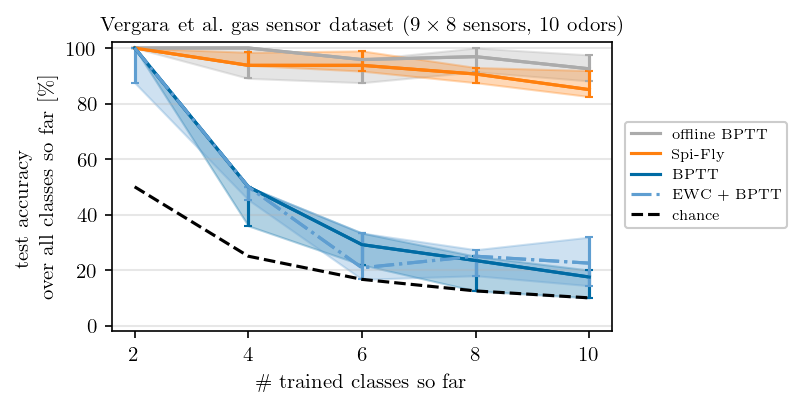

In [30]:
fig, ax = plt.subplots(figsize=(textwidth_in_cm * cm_to_inches / 1.4, 2.5))

plt.title("Vergara et al.~gas sensor dataset ($9 \\times 8$ sensors, 10 odors)", fontsize=10)

chance_levels = 100/(2*np.arange(1,N_epochs+1,1))

test_accs = [test_acc_offline_CL, test_acc_FlyModel_CL, test_acc_BPTT_CL, test_acc_EWC_CL]
epochs_per_odor = [5,1,1,1]
labels = ['offline BPTT', 'Spi-Fly', 'BPTT', 'EWC + BPTT']

colors = ['C2', 'C1', 'C0', 'C4', 'C6']
linestyles = ['solid', 'solid', 'solid', '-.',  'solid', 'solid']

for test_acc_arr, label, color, ls, epo in zip(test_accs, labels, colors, linestyles, epochs_per_odor):
    data = test_acc_arr.T[epo::epo]*100
    median = np.median(data, axis=1)
    q25, q75 = np.quantile(data, 0.25, axis=1), np.quantile(data, 0.75, axis=1)
    x = range(len(data))
    
    plt.errorbar(x, median, yerr=np.vstack([median-q25, q75-median]), c=color, ls=ls)
    ax.plot(median, color=color, label=label, ls=ls)
    ax.fill_between(x, q25, q75, alpha=0.3, color=color)

ax.plot(chance_levels, alpha = 1.0, ls='--', color='k', label='chance')
    

# plt.axhline(100/N_odors, alpha = 1.0, ls='--', color='k', label='chance')

plt.xlabel('\# trained classes so far')
plt.ylabel('test accuracy \\\ over all classes so far [\%]')
plt.xlim(-0.2,4.2)
plt.ylim(-2,102)


ticks = range(N_epochs)
ax.set_xticks(ticks)

tick_labels = [item.get_text() for item in ax.get_xticklabels()]
tick_labels = np.arange(2,N_odors+1,2)
ax.set_xticklabels(tick_labels)

# ax.annotate("add classes", xytext=(0.0, 3), xy=(4, 5),
#             arrowprops=dict(facecolor='black',width=0.1,lw=0.3,headwidth=5,headlength=7))

plt.grid(alpha=0.3, axis='y', linewidth=1.0)
# plt.axvline(1, alpha=0.3, color='k', linewidth=0.3)
# plt.axvline(12, alpha=0.2, color='k', linewidth=0.7)
# plt.axvline(120, alpha=0.2, color='k', linewidth=0.7)
plt.legend(prop={'size': 7}, framealpha=1.0, bbox_to_anchor=(1.365, 0.75))
plt.savefig('saved_figs/gas_sensor_CL.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Memory comparison

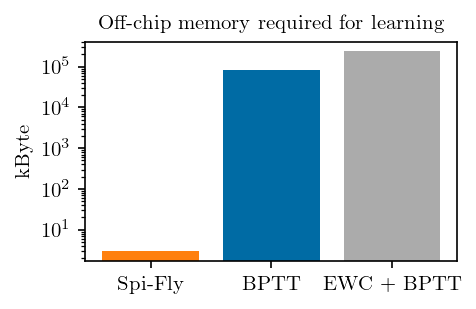

In [31]:
# for Spi-Fly, we only need to record the hidden layer spike count
# for BPTT, we take the forward/backward pass size
# for EWC, we take the forward/backward pass size plus input size for whole data set, e.g. 100
mem_size_kB = [3, 82.86*1024, (82.86 + 1.48*100)*1024]
labels = ['Spi-Fly', 'BPTT', 'EWC + BPTT']
colors = ['C1', 'C0', 'C2']

fig, ax = plt.subplots(figsize=(3.2, 1.9))

for x, y, lab, col in zip(range(3), mem_size_kB, labels, colors):
    plt.bar(x, y, label=lab, color=col)
plt.yscale('log')
plt.title('Off-chip memory required for learning', fontsize=10)
plt.ylabel('kByte')
plt.xticks([0,1,2], labels, size=10)
plt.savefig('saved_figs/mem.pdf', dpi=300, bbox_inches='tight')
plt.show()